In [124]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("../data/cfpb_sample_50k.csv")
df.head()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Submitted via,Date sent to company,Company response to consumer,Timely response?,Complaint ID
0,2026-05-13,Mortgage,Conventional home mortgage,Trouble during payment process,"Escrow, taxes, or insurance",The mortgage company failed to pay taxes for X...,Company believes it acted appropriately as aut...,"Shellpoint Partners, LLC",PA,18201,NaN,Web,2026-05-13,Closed with explanation,Yes,22147022
1,2026-06-24,Debt collection,Other debt,Attempts to collect debt not owed,Debt was paid,I am filing this complaint against Equifax and...,NaN,"EQUIFAX, INC.",WV,259XX,NaN,Web,2026-06-24,Closed with explanation,Yes,23524328
2,2026-07-08,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Public record information inaccurate,I am filing this complaint because I believe E...,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,GA,30094,NaN,Web,2026-07-08,Closed with explanation,Yes,23972021
3,2026-06-11,Debt collection,Credit card debt,Electronic communications,Frequent or repeated messages,This dedt was charged off back in 2020 by XXXX...,Company believes it acted appropriately as aut...,"MRS BPO, LLC",GA,30035,NaN,Web,2026-06-11,Closed with non-monetary relief,Yes,23125571
4,2026-05-28,Vehicle loan or lease,Loan,Problem with a company's investigation into an...,Their investigation did not fix an error on yo...,I called Bridgecrest and they confirmed that m...,NaN,Bridgecrest Acceptance Corporation,CT,06902,NaN,Web,2026-05-28,Closed with explanation,Yes,22652006


In [126]:
data = df.copy()
data.head()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Submitted via,Date sent to company,Company response to consumer,Timely response?,Complaint ID
0,2026-05-13,Mortgage,Conventional home mortgage,Trouble during payment process,"Escrow, taxes, or insurance",The mortgage company failed to pay taxes for X...,Company believes it acted appropriately as aut...,"Shellpoint Partners, LLC",PA,18201,NaN,Web,2026-05-13,Closed with explanation,Yes,22147022
1,2026-06-24,Debt collection,Other debt,Attempts to collect debt not owed,Debt was paid,I am filing this complaint against Equifax and...,NaN,"EQUIFAX, INC.",WV,259XX,NaN,Web,2026-06-24,Closed with explanation,Yes,23524328
2,2026-07-08,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Public record information inaccurate,I am filing this complaint because I believe E...,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,GA,30094,NaN,Web,2026-07-08,Closed with explanation,Yes,23972021
3,2026-06-11,Debt collection,Credit card debt,Electronic communications,Frequent or repeated messages,This dedt was charged off back in 2020 by XXXX...,Company believes it acted appropriately as aut...,"MRS BPO, LLC",GA,30035,NaN,Web,2026-06-11,Closed with non-monetary relief,Yes,23125571
4,2026-05-28,Vehicle loan or lease,Loan,Problem with a company's investigation into an...,Their investigation did not fix an error on yo...,I called Bridgecrest and they confirmed that m...,NaN,Bridgecrest Acceptance Corporation,CT,06902,NaN,Web,2026-05-28,Closed with explanation,Yes,22652006


In [127]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   Date received                 50000 non-null  str  
 1   Product                       50000 non-null  str  
 2   Sub-product                   50000 non-null  str  
 3   Issue                         50000 non-null  str  
 4   Sub-issue                     37903 non-null  str  
 5   Consumer complaint narrative  50000 non-null  str  
 6   Company public response       18330 non-null  str  
 7   Company                       50000 non-null  str  
 8   State                         49599 non-null  str  
 9   ZIP code                      49764 non-null  str  
 10  Tags                          8511 non-null   str  
 11  Submitted via                 50000 non-null  str  
 12  Date sent to company          50000 non-null  str  
 13  Company response to consumer  50000 non-nu

Product
Mortgage                                                   6250
Debt collection                                            6250
Credit reporting or other personal consumer reports        6250
Vehicle loan or lease                                      6250
Payday loan, title loan, personal loan, or advance loan    6250
Credit card                                                6250
Money transfer, virtual currency, or money service         6250
Checking or savings account                                6250
Name: count, dtype: int64


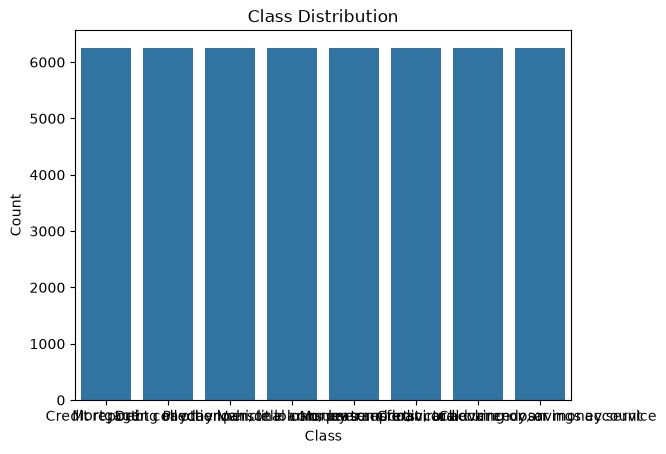

In [128]:
# Class counts
print(data["Product"].value_counts())

# Bar chart
sns.countplot(data, x="Product")
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

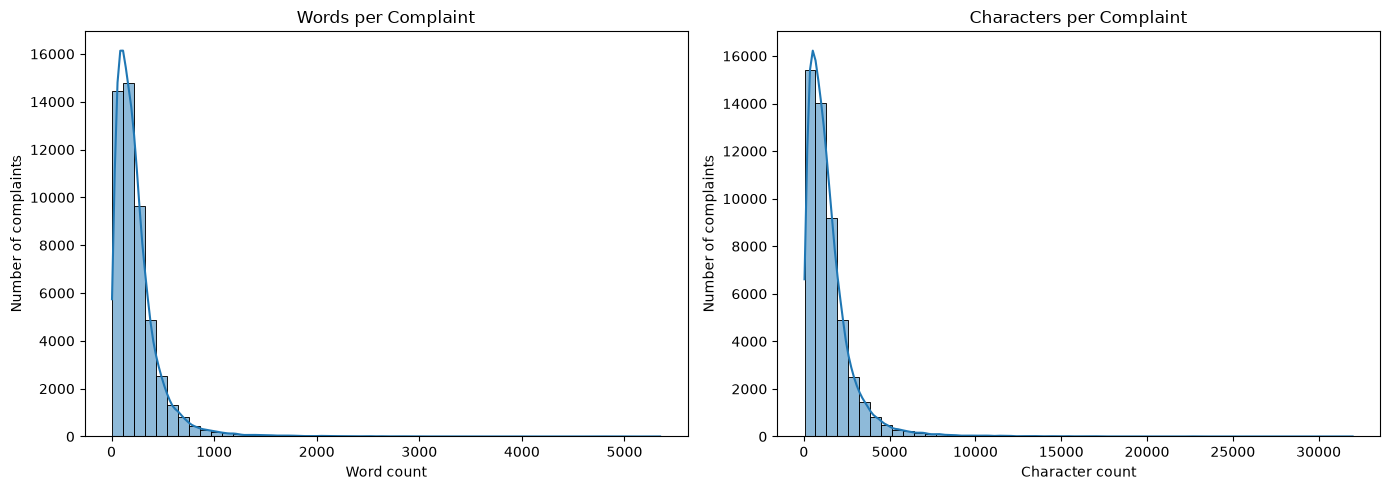

In [ ]:
data["word_count"] = (
    data["Consumer complaint narrative"].fillna("").astype(str).str.split().str.len()
)
data["char_count"] = (
    data["Consumer complaint narrative"].fillna("").astype(str).str.len()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data["word_count"], bins=50, kde=True, ax=axes[0])
axes[0].set_title("Words per Complaint")
axes[0].set_xlabel("Word count")
axes[0].set_ylabel("Number of complaints")

sns.histplot(data["char_count"], bins=50, kde=True, ax=axes[1])
axes[1].set_title("Characters per Complaint")
axes[1].set_xlabel("Character count")
axes[1].set_ylabel("Number of complaints")

plt.tight_layout()
plt.show()

In [ ]:
import re

text_col = "Consumer complaint narrative"


def clean_text(text):
    text = str(text).lower()

    # Remove redaction placeholders such as XXXX, XXXXX, or xx/xx/xxxx
    text = re.sub(r"\bx{2,}\b", " ", text)
    text = re.sub(r"\bx{2,}/x{2,}/x{2,}\b", " ", text)

    # Remove email addresses
    text = re.sub(r"\b[\w.-]+@[\w.-]+\.\w+\b", " ", text)

    # Remove URLs
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)

    # Remove phone-number-like patterns
    text = re.sub(r"\b(?:\+?1[-.\s]?)?\(?\d{3}\)?[-.\s]?\d{3}[-.\s]?\d{4}\b", " ", text)

    # Remove extra punctuation and whitespace
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text


data["clean_complaint_text"] = data[text_col].apply(clean_text)

In [132]:
(data["clean_complaint_text"].str.len() == 0).sum()

np.int64(6)

In [133]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 19 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   Date received                 50000 non-null  str  
 1   Product                       50000 non-null  str  
 2   Sub-product                   50000 non-null  str  
 3   Issue                         50000 non-null  str  
 4   Sub-issue                     37903 non-null  str  
 5   Consumer complaint narrative  50000 non-null  str  
 6   Company public response       18330 non-null  str  
 7   Company                       50000 non-null  str  
 8   State                         49599 non-null  str  
 9   ZIP code                      49764 non-null  str  
 10  Tags                          8511 non-null   str  
 11  Submitted via                 50000 non-null  str  
 12  Date sent to company          50000 non-null  str  
 13  Company response to consumer  50000 non-nu

In [134]:
data.drop_duplicates(inplace=True)

In [135]:
data.shape

(50000, 19)

In [ ]:
data.drop(
    columns=[c for c in data.columns if c not in ["clean_complaint_text", "Product"]],
    inplace=True,
)

In [ ]:
data.dropna(subset=["clean_complaint_text", "Product"], inplace=True)

In [138]:
print(data.shape)
data.info()

(50000, 2)
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Product               50000 non-null  str  
 1   clean_complaint_text  50000 non-null  str  
dtypes: str(2)
memory usage: 66.6 MB


In [139]:
data.head()

,Product,clean_complaint_text
0,Mortgage,the mortgage company failed to pay taxes for a...
1,Debt collection,i am filing this complaint against equifax and...
2,Credit reporting or other personal consumer re...,i am filing this complaint because i believe e...
3,Debt collection,this dedt was charged off back in 2020 by i ha...
4,Vehicle loan or lease,i called bridgecrest and they confirmed that m...


In [ ]:
from sklearn.model_selection import train_test_split

text_col = "clean_complaint_text"
target_col = "Product"

train, temp = train_test_split(
    data, test_size=0.30, stratify=data[target_col], random_state=42
)

val, test = train_test_split(
    temp, test_size=0.50, stratify=temp[target_col], random_state=42
)

train.to_parquet("../data/train.parquet", index=False)
val.to_parquet("../data/val.parquet", index=False)
test.to_parquet("../data/test.parquet", index=False)

print(f"Train: {len(train)} rows")
print(f"Validation: {len(val)} rows")
print(f"Test: {len(test)} rows")

Train: 35000 rows
Validation: 7500 rows
Test: 7500 rows


In [ ]:
from collections import Counter
import re

text_col = "clean_complaint_text"
category_col = "Product"

stopwords = {
    "the", "and", "is", "to", "of", "in", "for", "on",
    "a", "an", "was", "with", "that", "this", "it",
    "my", "i", "have", "has", "had", "be", "as", "at",
    "they", "or", "me", "from", "am", "by", "been", "s",
    "were", "are", "but", "would", "which", "these", "did"
}


def get_common_words(texts, n=20):
    words = []

    for text in texts.dropna():
        tokens = text.lower().split()

        # Keep alphabetic words and remove stopwords
        words.extend(
            word for word in tokens
            if word.isalpha() and word not in stopwords
        )
        
    return Counter(words).most_common(n)


overall_words = get_common_words(data[text_col], n=20)

print("Most common words overall:")
print(overall_words)

Most common words overall:
[('account', 108960), ('not', 107295), ('credit', 65119), ('payment', 47486), ('information', 38081), ('no', 37850), ('any', 35692), ('loan', 35686), ('bank', 35153), ('year', 33126), ('reporting', 32711), ('all', 29414), ('dispute', 25740), ('balance', 25633), ('under', 25046), ('after', 24985), ('received', 24208), ('complaint', 23848), ('report', 23759), ('request', 23573)]


In [ ]:
categories = data[category_col].value_counts().index

for category in categories:
    category_text = data.loc[data[category_col] == category, text_col]

    common_words = get_common_words(category_text, n=15)

    print(f"\nCategory: {category}")
    print(common_words)


Category: Mortgage
[('not', 17397), ('mortgage', 16780), ('payment', 13444), ('loan', 12728), ('account', 8673), ('escrow', 7382), ('we', 6846), ('no', 6710), ('payments', 6292), ('year', 6253), ('servicing', 4973), ('received', 4959), ('property', 4928), ('all', 4846), ('any', 4758)]

Category: Debt collection
[('account', 15461), ('debt', 14266), ('not', 10864), ('credit', 10772), ('collection', 8394), ('reporting', 8177), ('information', 6219), ('any', 5877), ('report', 4880), ('request', 4690), ('you', 4630), ('documentation', 4422), ('all', 4232), ('under', 4226), ('validation', 4183)]

Category: Credit reporting or other personal consumer reports
[('credit', 17270), ('reporting', 12085), ('account', 11441), ('information', 10481), ('not', 9493), ('report', 9099), ('accounts', 7162), ('consumer', 6679), ('under', 6186), ('u', 5862), ('inaccurate', 5769), ('fcra', 5396), ('c', 4789), ('reported', 4738), ('any', 4321)]

Category: Vehicle loan or lease
[('not', 13679), ('vehicle', 1